LSMS panel: (1350540, 18)
Yield df (raw): (28445, 115)
EE / satellite: (6187, 115)
Yield df (clean): (22881, 115)
Grouping yields by keys: ['ea_id_obs', 'ea_id_merge', 'lat_modified', 'lon_modified']
Aggregated yields: (3418, 6)


/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_25684/3387887017.py:28: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  yield_df = pd.read_stata(yield_path)


LSMS with yields: (1350540, 20)
Non-null log_yield rows: 454320
LSMS with yields (filtered): (454320, 20)
Final merged df (LSMS+yield+EE): (585180, 131)
Feature matrix X: (585180, 117)
Target y length: 585180

🌍 Global results: {'RF': 0.9143110260419148, 'XGB': 0.944436042523549}

🌎 Country-specific models



Countries:   0%|          | 0/7 [00:00<?, ?it/s]

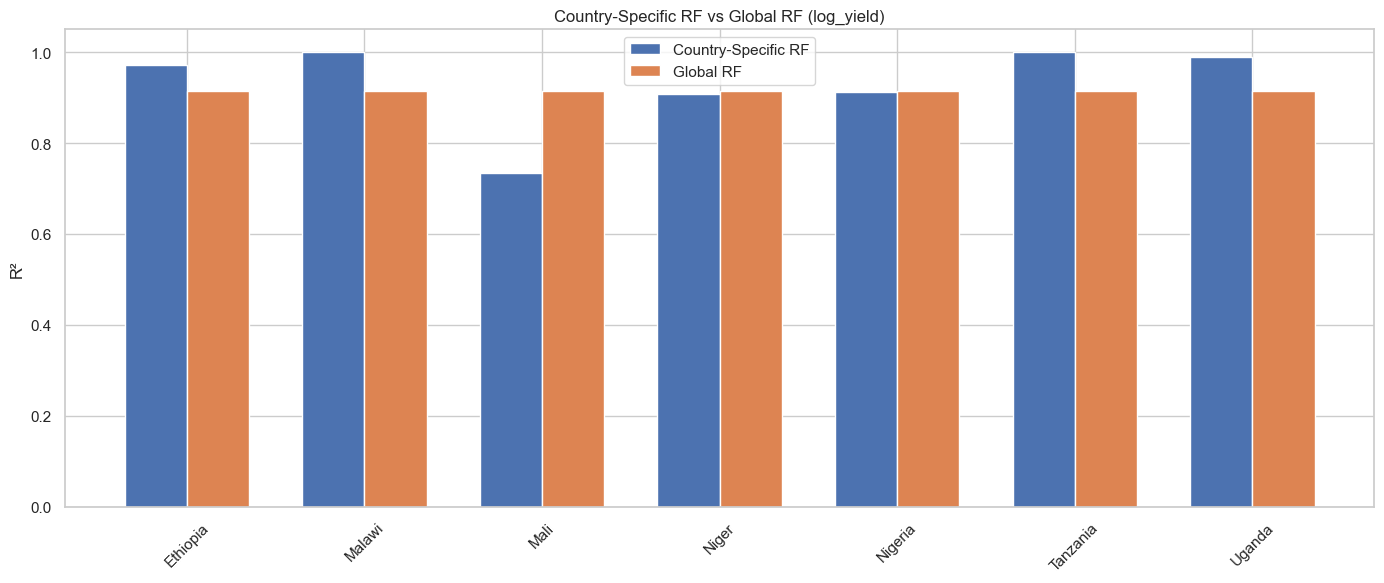

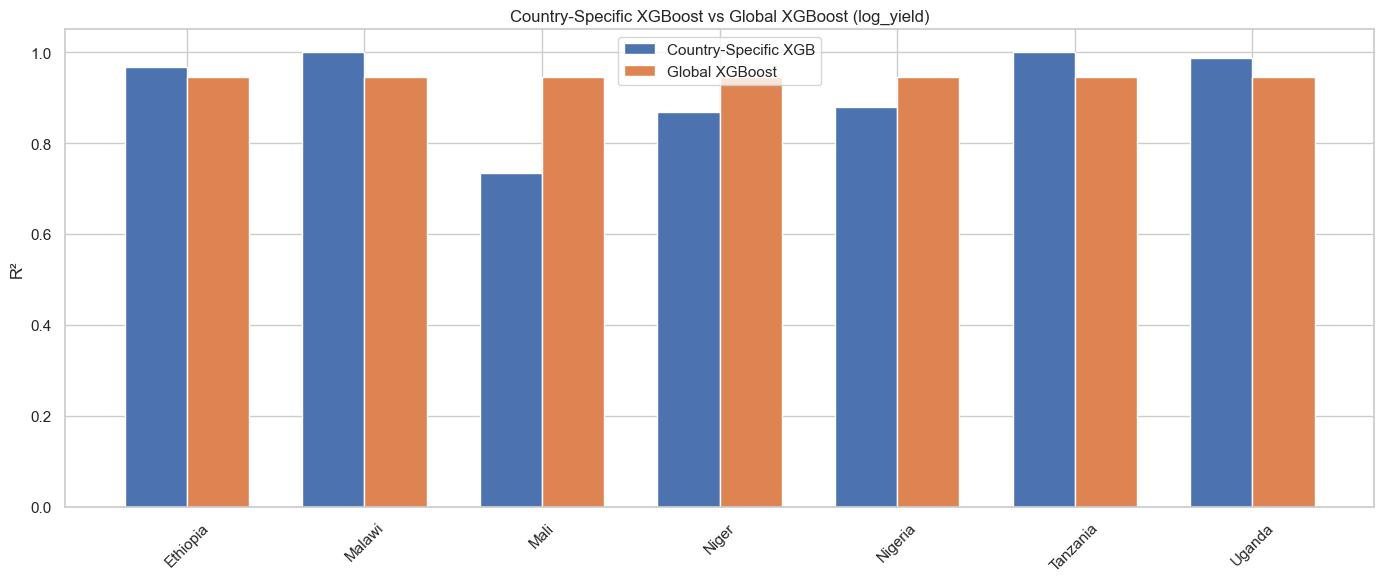

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. File paths (edit these if needed)
# ----------------------------------------------------------
lsms_path  = "/Users/jjburrell/Downloads/send/lsms_panel_allvars_2010_2024_MASTER.csv"
yield_path = "/Users/jjburrell/Downloads/Plot_dataset.dta"  # <-- yields here
ee_path    = "/Users/jjburrell/Downloads/send/EE_harvest_ml.csv"

# ----------------------------------------------------------
# 2. Load data
# ----------------------------------------------------------
# LSMS panel (weather/time series)
lsms = pd.read_csv(lsms_path, low_memory=False)
print("LSMS panel:", lsms.shape)

# Yield data (plot-level LSMS)
yield_df = pd.read_stata(yield_path)
print("Yield df (raw):", yield_df.shape)

# Satellite / EE features
ee = pd.read_csv(ee_path)
print("EE / satellite:", ee.shape)

# ----------------------------------------------------------
# 3. Clean + aggregate yields
# ----------------------------------------------------------
# Keep plausible yields and valid coordinates
yield_df = yield_df[(yield_df["yield_kg"] > 0) & (yield_df["yield_kg"] < 15000)]
yield_df = yield_df.dropna(subset=["yield_kg", "lat_modified", "lon_modified"])
print("Yield df (clean):", yield_df.shape)

# We want to aggregate to keys that exist in BOTH LSMS and yield_df.
candidate_keys = [
    "country", "wave", "season",
    "ea_id_obs", "ea_id_merge",
    "lat_modified", "lon_modified",
    "year", "month", "ym",
]

group_keys = [k for k in candidate_keys if k in yield_df.columns and k in lsms.columns]

if not group_keys:
    raise ValueError(
        f"No common grouping keys between LSMS and yield_df. "
        f"Check that columns like 'country', 'wave', 'ea_id_obs', etc. "
        f"exist in BOTH."
    )

print("Grouping yields by keys:", group_keys)

agg_yields = (
    yield_df.groupby(group_keys)
    .agg(mean_yield=("yield_kg", "mean"))
    .reset_index()
)

agg_yields["log_yield"] = np.log1p(agg_yields["mean_yield"])
print("Aggregated yields:", agg_yields.shape)

# ----------------------------------------------------------
# 4. Append yields to LSMS panel (just yields)
# ----------------------------------------------------------
lsms_with_yield = lsms.merge(agg_yields, on=group_keys, how="left")
print("LSMS with yields:", lsms_with_yield.shape)
print("Non-null log_yield rows:",
      lsms_with_yield["log_yield"].notna().sum())

# Keep only rows where we actually have yield info
lsms_with_yield = lsms_with_yield[lsms_with_yield["log_yield"].notna()]
print("LSMS with yields (filtered):", lsms_with_yield.shape)

# ----------------------------------------------------------
# 5. Merge LSMS+yield with EE features
#    using your EA/location keys
# ----------------------------------------------------------
merge_keys_ee = ["ea_id_obs", "ea_id_merge", "lat_modified", "lon_modified"]

for k in merge_keys_ee:
    assert k in lsms_with_yield.columns, f"{k} missing in LSMS+yield"
    assert k in ee.columns, f"{k} missing in EE"

df = lsms_with_yield.merge(ee, on=merge_keys_ee, how="inner")
df = df.dropna(subset=["log_yield"])
print("Final merged df (LSMS+yield+EE):", df.shape)

if "country" not in df.columns:
    raise ValueError(
        "Final merged df has no 'country' column. "
        "Check that EE_harvest_ml.csv has 'country' and merge keys are correct."
    )

# ----------------------------------------------------------
# 6. Define features X and target y
# ----------------------------------------------------------
target = "log_yield"

# Drop obvious non-feature columns
drop_cols = (
    [target, "mean_yield", "source_file", "date"] +
    merge_keys_ee +
    [k for k in ["country", "wave", "season", "year", "month", "ym"]
     if k in df.columns]
)

drop_cols = list(dict.fromkeys(c for c in drop_cols if c in df.columns))  # unique & present

X = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
y = df[target]

print("Feature matrix X:", X.shape)
print("Target y length:", len(y))

# ----------------------------------------------------------
# 7. Helper: train RF + XGB on a split
# ----------------------------------------------------------
def run_models(X_train, X_test, y_train, y_test):
    results = {}

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    results["RF"] = r2_score(y_test, y_pred_rf)

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",  # CPU-friendly
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    results["XGB"] = r2_score(y_test, y_pred_xgb)

    return results

# ----------------------------------------------------------
# 8. Global train/test and models
# ----------------------------------------------------------
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X, y, test_size=0.2, random_state=42
)

global_results = run_models(X_train_g, X_test_g, y_train_g, y_test_g)
print("\n🌍 Global results:", global_results)

# ----------------------------------------------------------
# 9. Country-specific RF + XGB
# ----------------------------------------------------------
countries = sorted(df["country"].unique())

rf_country_scores = []
xgb_country_scores = []

print("\n🌎 Country-specific models\n")
for c in tqdm(countries, desc="Countries"):
    d = df[df["country"] == c]

    if len(d) < 30:
        print(f"Skipping {c}: only {len(d)} rows")
        rf_country_scores.append(np.nan)
        xgb_country_scores.append(np.nan)
        continue

    Xc = d.drop(columns=drop_cols).select_dtypes(include=[np.number])
    yc = d[target]

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        Xc, yc, test_size=0.2, random_state=42
    )

    scores = run_models(X_train_c, X_test_c, y_train_c, y_test_c)
    rf_country_scores.append(scores["RF"])
    xgb_country_scores.append(scores["XGB"])

# ----------------------------------------------------------
# 10. Plot R² — RF
# ----------------------------------------------------------
sns.set(style="whitegrid")
x_idx = np.arange(len(countries))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x_idx - width/2, rf_country_scores, width, label="Country-Specific RF")
plt.bar(x_idx + width/2, [global_results["RF"]] * len(countries), width,
        label="Global RF")

plt.xticks(x_idx, countries, rotation=45)
plt.ylabel("R²")
plt.title("Country-Specific RF vs Global RF (log_yield)")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 11. Plot R² — XGBoost
# ----------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.bar(x_idx - width/2, xgb_country_scores, width, label="Country-Specific XGB")
plt.bar(x_idx + width/2, [global_results["XGB"]] * len(countries), width,
        label="Global XGBoost")

plt.xticks(x_idx, countries, rotation=45)
plt.ylabel("R²")
plt.title("Country-Specific XGBoost vs Global XGBoost (log_yield)")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
lsms.columns

Index(['ea_id_obs', 'ea_id_merge', 'lat_modified', 'lon_modified', 'year',
       'month', 'ym', 'precip', 'tmax', 'tmin', 'soil_moist', 'NDVI', 'EVI',
       'GCVI', 'GDD', 'KDD', 'source_file', 'date'],
      dtype='object')

In [4]:
ee.columns

Index(['country', 'wave', 'season', 'ea_id_obs', 'ea_id_merge', 'lat_modified',
       'lon_modified', 'EVI_0', 'EVI_1', 'EVI_10',
       ...
       'tmin_10', 'tmin_11', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6',
       'tmin_7', 'tmin_8', 'tmin_9'],
      dtype='object', length=115)